# 08 - Visualizations

This notebook creates presentation-ready images for the docs folder.

Outputs:
- `docs/images/time_series_context.png`
- `docs/images/sarima_showcase.png`
- `docs/images/lstm_showcase.png`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED = ROOT / "data" / "processed"
DOC_IMAGES = ROOT / "docs" / "images"
DOC_IMAGES.mkdir(parents=True, exist_ok=True)

daily_df = pd.read_csv(PROCESSED / "focus_age_daily_arrivals.csv", parse_dates=["admission_date"])
stat_df = pd.read_csv(PROCESSED / "statistical_model_predictions.csv", parse_dates=["admission_date"])
lstm_df = pd.read_csv(PROCESSED / "lstm_model_predictions.csv", parse_dates=["admission_date"])

observed_end = stat_df.loc[stat_df["arrivals"].notna(), "admission_date"].max()


def first_arrival_distribution(future_df, prediction_col):
    lambdas = future_df[prediction_col].fillna(0).clip(lower=0).to_numpy(dtype=float)
    no_arrival_prefix = np.exp(-np.cumsum(np.r_[0.0, lambdas[:-1]]))
    first_arrival_prob = no_arrival_prefix * (1 - np.exp(-lambdas))
    return pd.DataFrame(
        {
            "admission_date": future_df["admission_date"].to_numpy(),
            "first_arrival_probability": first_arrival_prob,
        }
    )


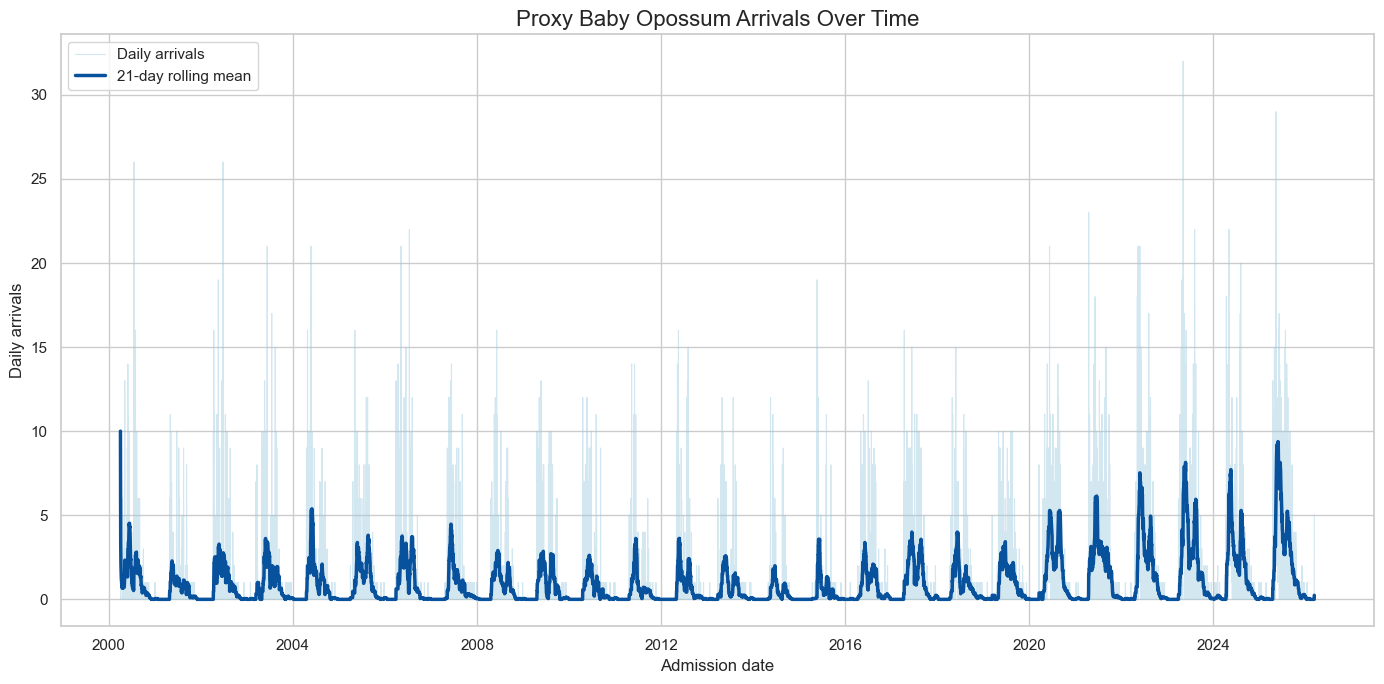

In [2]:
plot_df = daily_df[["admission_date", "arrivals"]].copy()
plot_df["rolling_21d"] = plot_df["arrivals"].rolling(21, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(plot_df["admission_date"], plot_df["arrivals"], color="#9ecae1", linewidth=0.8, alpha=0.45, label="Daily arrivals")
ax.plot(plot_df["admission_date"], plot_df["rolling_21d"], color="#08519c", linewidth=2.5, label="21-day rolling mean")
ax.set_title("Proxy Baby Opossum Arrivals Over Time")
ax.set_xlabel("Admission date")
ax.set_ylabel("Daily arrivals")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "time_series_context.png", dpi=200, bbox_inches="tight")
plt.show()


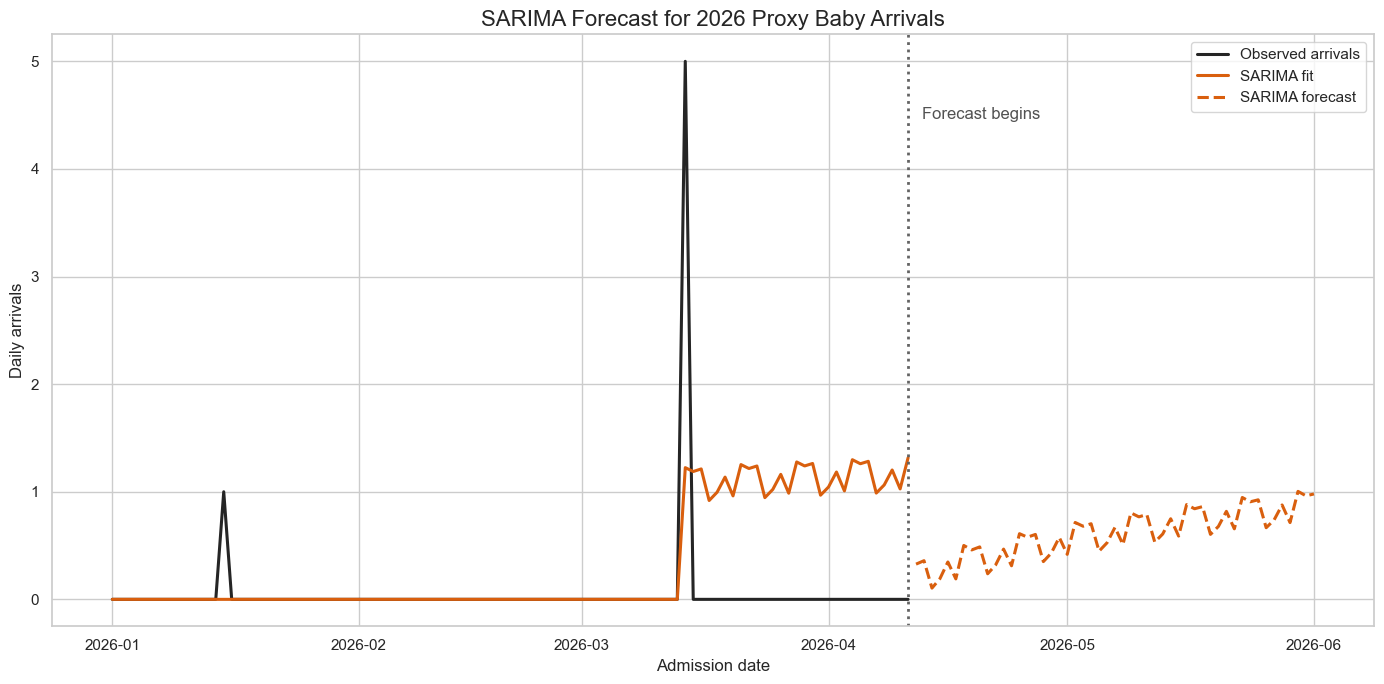

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

observed = stat_df[stat_df["admission_date"] <= observed_end].copy()
future = stat_df[stat_df["admission_date"] > observed_end].copy()

ax.plot(observed["admission_date"], observed["arrivals"], color="#252525", linewidth=2.2, label="Observed arrivals")
ax.plot(observed["admission_date"], observed["sarimax_pred"], color="#d95f0e", linewidth=2.2, label="SARIMA fit")
ax.plot(future["admission_date"], future["sarimax_pred"], color="#d95f0e", linewidth=2.2, linestyle="--", label="SARIMA forecast")
ax.axvline(observed_end, color="#636363", linestyle=":", linewidth=2)
ax.annotate("Forecast begins", xy=(observed_end, ax.get_ylim()[1] * 0.85), xytext=(10, 0), textcoords="offset points", color="#525252")
ax.set_title("SARIMA Forecast for 2026 Proxy Baby Arrivals")
ax.set_xlabel("Admission date")
ax.set_ylabel("Daily arrivals")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "sarima_showcase.png", dpi=200, bbox_inches="tight")
plt.show()


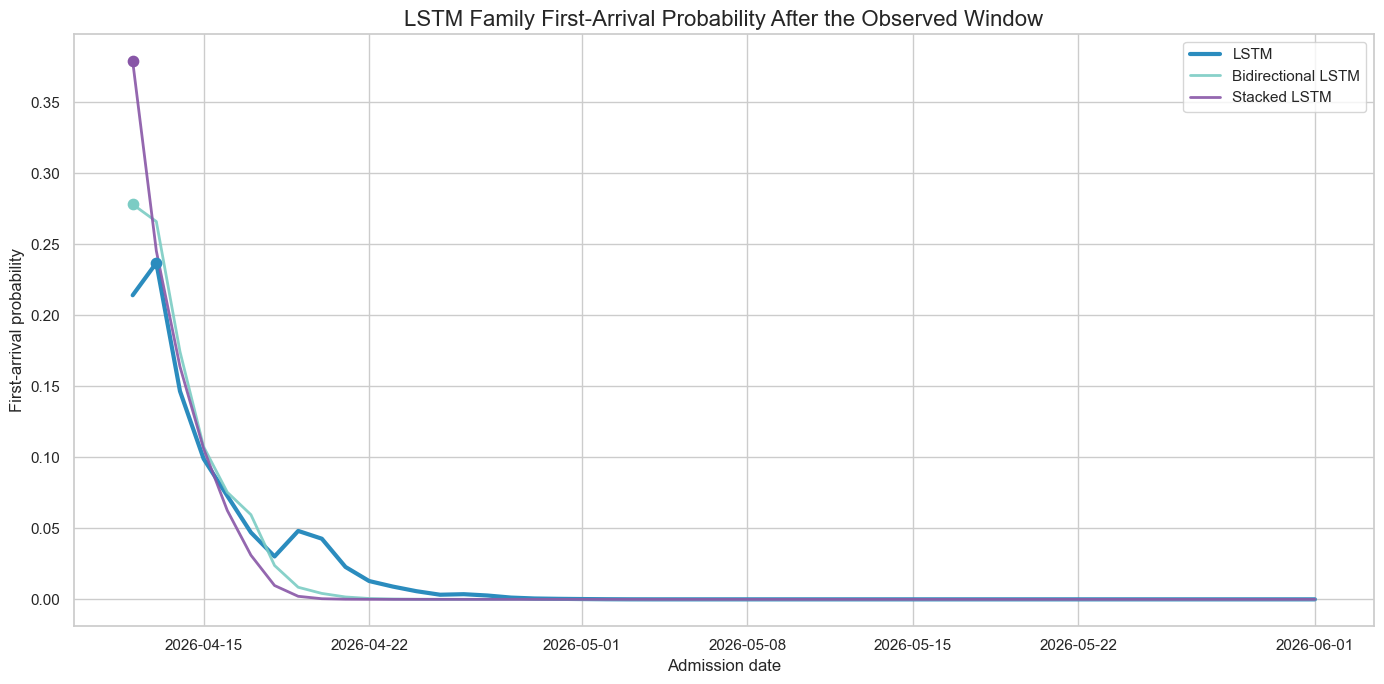

In [4]:
future_lstm = lstm_df[lstm_df["arrivals"].isna()].copy()

model_styles = {
    "LSTM_pred": {"label": "LSTM", "color": "#2b8cbe", "linewidth": 3.0, "alpha": 1.0},
    "Bidirectional LSTM_pred": {"label": "Bidirectional LSTM", "color": "#7bccc4", "linewidth": 2.0, "alpha": 0.9},
    "Stacked LSTM_pred": {"label": "Stacked LSTM", "color": "#8856a7", "linewidth": 2.0, "alpha": 0.9},
}

fig, ax = plt.subplots(figsize=(14, 7))

for col, style in model_styles.items():
    curve = first_arrival_distribution(future_lstm, col)
    ax.plot(
        curve["admission_date"],
        curve["first_arrival_probability"],
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"],
        label=style["label"],
    )
    peak = curve.loc[curve["first_arrival_probability"].idxmax()]
    ax.scatter(peak["admission_date"], peak["first_arrival_probability"], color=style["color"], s=55, zorder=3)

ax.set_title("LSTM Family First-Arrival Probability After the Observed Window")
ax.set_xlabel("Admission date")
ax.set_ylabel("First-arrival probability")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "lstm_showcase.png", dpi=200, bbox_inches="tight")
plt.show()
